# Projet 5 | Classification d'articles de presse (Partie II)

Notebook d'entraînement et de comparaison.

**CSV** : `data/dataset_valide.csv`

| Colonne | Description |
|---------|-------------|
| `titre` | Titre de l'article |
| `contenu_nettoye` | Texte nettoyé |
| `categorie` | Étiquette validée |



In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
import json

import joblib
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

# Depuis notebooks/ → remonter à la racine du projet
NOTEBOOK_DIR = Path.cwd()
BASE_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = BASE_DIR / "data" / "dataset_valide.csv"
MODEL_DIR = BASE_DIR / "models" / "camembert-classifieur"
PROD_MODEL_DIR = BASE_DIR / "models" / "tfidf-svm-optimise"
RANDOM_STATE = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
print("CSV:", DATA_PATH)

Device: cpu
CSV: c:\Users\DarkSide\Downloads\nlp\data\dataset_valide.csv


## 1. Chargement des données

In [2]:
df = pd.read_csv(DATA_PATH)
df["texte"] = (df["titre"].astype(str) + " " + df["contenu_nettoye"].astype(str)).str.strip()
df = df[df["categorie"].notna() & (df["categorie"].astype(str).str.len() > 0)]
df = df[df["texte"].str.len() > 50].reset_index(drop=True)

print(f"Articles : {len(df)}")
print(f"Catégories : {df['categorie'].nunique()}")
df["categorie"].value_counts()

Articles : 372
Catégories : 8


categorie
Sport        98
Politique    67
Économie     56
Société      39
Sécurité     34
Éducation    30
Santé        26
Culture      22
Name: count, dtype: int64

## 2. Split train / test

In [3]:
labels = sorted(df["categorie"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

# Stratification possible uniquement si chaque classe a >= 2 articles
counts = df["categorie"].value_counts()
can_stratify = counts.min() >= 2
if not can_stratify:
    rares = counts[counts < 2].index.tolist()
    print("Attention : classes trop rares pour la stratification:", rares)

y_all = df["categorie"].map(label2id)
X_train, X_test, y_train, y_test = train_test_split(
    df["texte"],
    y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all if can_stratify else None,
)

print("Train:", len(X_train), "| Test:", len(X_test))
print("Labels:", labels)

Train: 297 | Test: 75
Labels: ['Culture', 'Politique', 'Santé', 'Société', 'Sport', 'Sécurité', 'Économie', 'Éducation']


## 3. Baselines classiques (BoW, TF-IDF)

Comparaison demandée par le sujet : vectorisation + classifieurs simples.

In [4]:
def eval_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f} | F1 pondéré: {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))
    return {"modele": name, "accuracy": acc, "f1_weighted": f1}


baselines = {
    "BoW + Naive Bayes": Pipeline([
        ("vec", CountVectorizer(max_features=20000, ngram_range=(1, 2))),
        ("clf", MultinomialNB()),
    ]),
    "TF-IDF + SVM": Pipeline([
        ("vec", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ("clf", LinearSVC()),
    ]),
    "TF-IDF + Régression logistique": Pipeline([
        ("vec", TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
}

results = []
for name, pipe in baselines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results.append(eval_model(name, y_test, preds))


=== BoW + Naive Bayes ===
Accuracy: 0.6400 | F1 pondéré: 0.6360
              precision    recall  f1-score   support

     Culture       0.50      0.50      0.50         4
   Politique       0.59      0.71      0.65        14
       Santé       0.50      0.40      0.44         5
     Société       0.31      0.62      0.42         8
       Sport       1.00      0.90      0.95        20
    Sécurité       0.67      0.29      0.40         7
    Économie       0.67      0.73      0.70        11
   Éducation       1.00      0.17      0.29         6

    accuracy                           0.64        75
   macro avg       0.65      0.54      0.54        75
weighted avg       0.71      0.64      0.64        75


=== TF-IDF + SVM ===
Accuracy: 0.7600 | F1 pondéré: 0.7556
              precision    recall  f1-score   support

     Culture       0.60      0.75      0.67         4
   Politique       0.73      0.79      0.76        14
       Santé       0.57      0.80      0.67         5
     So

## 3 bis. Word2Vec + classifieur

On entraîne un Word2Vec sur le corpus, puis chaque document est représenté par la **moyenne** des vecteurs de ses mots. Un classifieur (régression logistique) apprend ensuite sur ces embeddings.

In [5]:
import re

from gensim.models import Word2Vec


def tokenize_simple(texte: str) -> list[str]:
    return re.findall(r"\b\w[\w'-]*\b", str(texte).lower())


train_tokens = [tokenize_simple(t) for t in X_train]
test_tokens = [tokenize_simple(t) for t in X_test]

W2V_DIM = 100
w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=W2V_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=RANDOM_STATE,
)


def document_vector(tokens: list[str]) -> np.ndarray:
    vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
    if not vecs:
        return np.zeros(W2V_DIM, dtype=np.float32)
    return np.mean(vecs, axis=0)


X_train_w2v = np.vstack([document_vector(t) for t in train_tokens])
X_test_w2v = np.vstack([document_vector(t) for t in test_tokens])

w2v_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
w2v_clf.fit(X_train_w2v, y_train)
w2v_preds = w2v_clf.predict(X_test_w2v)

results.append(eval_model("Word2Vec + Régression logistique", y_test, w2v_preds))


=== Word2Vec + Régression logistique ===
Accuracy: 0.4667 | F1 pondéré: 0.3808
              precision    recall  f1-score   support

     Culture       0.00      0.00      0.00         4
   Politique       0.37      0.79      0.50        14
       Santé       0.00      0.00      0.00         5
     Société       0.00      0.00      0.00         8
       Sport       0.86      0.90      0.88        20
    Sécurité       0.00      0.00      0.00         7
    Économie       0.27      0.55      0.36        11
   Éducation       0.00      0.00      0.00         6

    accuracy                           0.47        75
   macro avg       0.19      0.28      0.22        75
weighted avg       0.34      0.47      0.38        75



## 4. CamemBERT | fine-tuning

Modèle pré-entraîné français : `camembert-base`

In [6]:
MODEL_NAME = "camembert-base"
MAX_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)


def tokenize_batch(batch):
    return tokenizer(batch["texte"], truncation=True, max_length=MAX_LENGTH)


train_ds = Dataset.from_dict({"texte": X_train.tolist(), "label": y_train.tolist()})
test_ds = Dataset.from_dict({"texte": X_test.tolist(), "label": y_test.tolist()})

train_ds = train_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForSequenceClassification LOAD REPORT from: camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/297 [00:00<?, ? examples/s]

Map:   0%|          | 0/75 [00:00<?, ? examples/s]

In [7]:
def compute_metrics(eval_pred):
    logits, labels_eval = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels_eval, preds),
        "f1_weighted": f1_score(labels_eval, preds, average="weighted"),
    }


MODEL_DIR.mkdir(parents=True, exist_ok=True)

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

c:\Users\DarkSide\Downloads\nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,No log,1.927711,0.413333,0.260317
2,1.999889,1.808410,0.466667,0.372597
3,1.848258,1.758233,0.493333,0.402748


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\DarkSide\Downloads\nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\DarkSide\Downloads\nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=114, training_loss=1.89985944513689, metrics={'train_runtime': 482.3976, 'train_samples_per_second': 1.847, 'train_steps_per_second': 0.236, 'total_flos': 117222289772544.0, 'train_loss': 1.89985944513689, 'epoch': 3.0})

## 5. Évaluation CamemBERT

c:\Users\DarkSide\Downloads\nlp\venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== CamemBERT ===
Accuracy: 0.4933 | F1 pondéré: 0.4027
              precision    recall  f1-score   support

     Culture       0.00      0.00      0.00         4
   Politique       0.29      0.93      0.44        14
       Santé       0.00      0.00      0.00         5
     Société       0.00      0.00      0.00         8
       Sport       0.90      0.95      0.93        20
    Sécurité       0.00      0.00      0.00         7
    Économie       0.56      0.45      0.50        11
   Éducation       0.00      0.00      0.00         6

    accuracy                           0.49        75
   macro avg       0.22      0.29      0.23        75
weighted avg       0.38      0.49      0.40        75



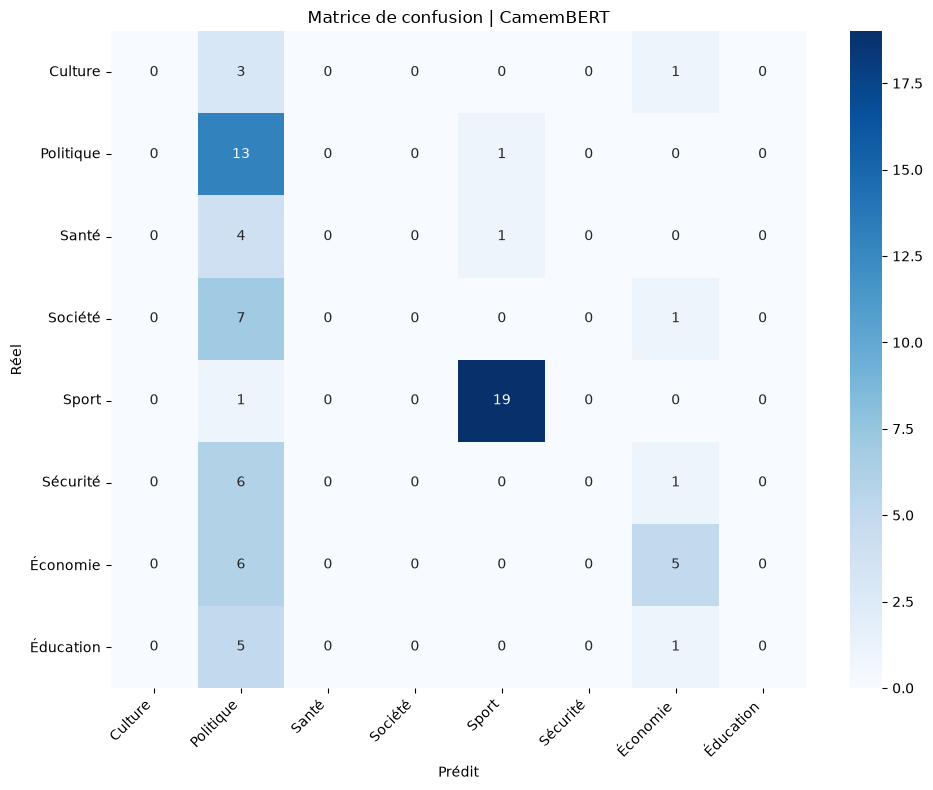

In [8]:
camembert_preds = trainer.predict(test_ds)
y_pred_cam = np.argmax(camembert_preds.predictions, axis=-1)

results.append(eval_model("CamemBERT", y_test, y_pred_cam))

cm = confusion_matrix(y_test, y_pred_cam)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion | CamemBERT")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Comparaison finale & sauvegarde

,modele,accuracy,f1_weighted
1,TF-IDF + SVM,0.760000,0.755566
0,BoW + Naive Bayes,0.640000,0.636022
2,TF-IDF + Régression logistique,0.613333,0.567439
4,CamemBERT,0.493333,0.402748
3,Word2Vec + Régression logistique,0.466667,0.380813


C:\Users\DarkSide\AppData\Local\Temp\ipykernel_7940\864943570.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="f1_weighted", y="modele", palette="viridis")


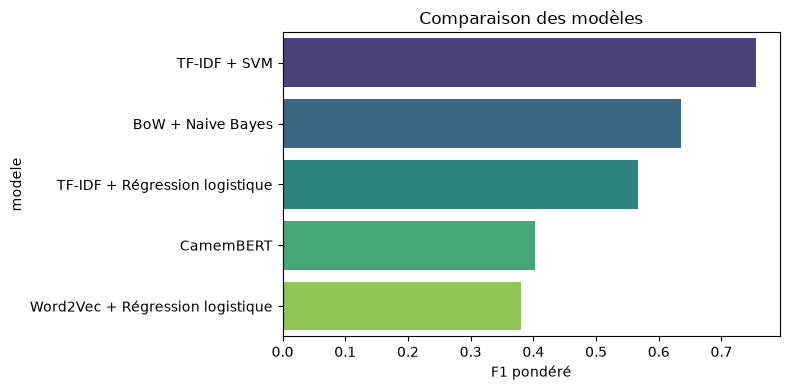

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modèle sauvegardé dans: c:\Users\DarkSide\Downloads\nlp\models\camembert-classifieur


In [13]:
comparison = pd.DataFrame(results).sort_values("f1_weighted", ascending=False)
display(comparison)

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x="f1_weighted", y="modele", palette="viridis")
plt.xlabel("F1 pondéré")
plt.title("Comparaison des modèles")
plt.tight_layout()
plt.show()

# Sauvegarde du modèle CamemBERT fine-tuné
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
comparison.to_csv(BASE_DIR / "data" / "resultats_comparaison.csv", index=False)
print("Modèle sauvegardé dans:", MODEL_DIR)

## 7. Optimisation
Pipeline retenu après la comparaison (section 6) : **TF-IDF + SVM**.

1. `GridSearchCV` sur le jeu d'entraînement
2. Évaluation sur le jeu de test
3. Réentraînement sur **tout** le corpus avec les meilleurs hyperparamètres
4. Sauvegarde pour le déploiement (étape 6)

In [17]:
import json

import joblib
from sklearn.model_selection import GridSearchCV

BEST_PIPELINE_NAME = "TF-IDF + SVM"

tuned_pipe = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LinearSVC(random_state=RANDOM_STATE)),
])

param_grid = {
    "vec__max_features": [10000, 20000, 30000],
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df": [1, 2],
    "clf__C": [0.1, 1, 10],
}

grid_search = GridSearchCV(
    tuned_pipe,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres :")
for key, value in grid_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"F1 pondéré (CV) : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average="weighted")

print(f"\n=== {BEST_PIPELINE_NAME} (optimisé) — jeu de test ===")
print(f"Accuracy: {tuned_acc:.4f} | F1 pondéré: {tuned_f1:.4f}")
print(classification_report(y_test, y_pred_tuned, target_names=labels, zero_division=0))

# Réentraînement final sur tout le corpus annoté
X_all = df["texte"]
y_all = df["categorie"].map(label2id)

final_model = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LinearSVC(random_state=RANDOM_STATE)),
])
final_model.set_params(**grid_search.best_params_)
final_model.fit(X_all, y_all)

PROD_MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, PROD_MODEL_DIR / "pipeline.joblib")

metadata = {
    "modele": BEST_PIPELINE_NAME,
    "labels": labels,
    "label2id": label2id,
    "best_params": {k: list(v) if isinstance(v, tuple) else v for k, v in grid_search.best_params_.items()},
    "cv_f1_weighted": float(grid_search.best_score_),
    "test_accuracy": float(tuned_acc),
    "test_f1_weighted": float(tuned_f1),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_total": int(len(X_all)),
}
with open(PROD_MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"\nModèle production sauvegardé : {PROD_MODEL_DIR / 'pipeline.joblib'}")
print(f"Métadonnées : {PROD_MODEL_DIR / 'metadata.json'}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Meilleurs hyperparamètres :
  clf__C: 10
  vec__max_features: 10000
  vec__min_df: 2
  vec__ngram_range: (1, 1)
F1 pondéré (CV) : 0.8003

=== TF-IDF + SVM (optimisé) — jeu de test ===
Accuracy: 0.7467 | F1 pondéré: 0.7418
              precision    recall  f1-score   support

     Culture       0.60      0.75      0.67         4
   Politique       0.69      0.79      0.73        14
       Santé       0.56      1.00      0.71         5
     Société       0.50      0.62      0.56         8
       Sport       1.00      0.95      0.97        20
    Sécurité       1.00      0.43      0.60         7
    Économie       0.73      0.73      0.73        11
   Éducation       1.00      0.33      0.50         6

    accuracy                           0.75        75
   macro avg       0.76      0.70      0.68        75
weighted avg       0.80      0.75      0.74        75


Modèle production sauvegardé : c:\Users\DarkSide\Downloads\nlp\m

## 8. Test sur un nouvel article (modèle optimisé)

Prédiction avec le pipeline **TF-IDF + SVM** sauvegardé pour l'étape 6.

In [18]:
def predict_article(texte: str, top_k: int = 3):
    """Scores de confiance via decision_function (normalisés en pseudo-probabilités)."""
    model = joblib.load(PROD_MODEL_DIR / "pipeline.joblib")
    scores = model.decision_function([texte])[0]
    exp_scores = np.exp(scores - scores.max())
    probs = exp_scores / exp_scores.sum()
    top_idx = probs.argsort()[::-1][:top_k]
    for i in top_idx:
        print(f"{labels[i]}: {probs[i]:.2%}")


exemple = "Le gouvernement adopte de nouvelles mesures économiques pour soutenir les PME."
predict_article(exemple)

Sport: 17.20%
Économie: 17.06%
Société: 16.31%
